# MEPDA: Machine Ensemble Learning for Postpartum Depression Assessment applied to Bangladeshi Women

## Data Preprocessing

### Load the dataset

In [37]:
import pandas as pd
csv_path = './data/PPD_dataset_v2.csv'

### Encode the data

In [38]:
import pandas as pd
import numpy as np

def analyze_and_encode_csv(csv_path):
    # Read the CSV file
    df = pd.read_csv(csv_path)

    # Replace the value in column 'F' and row 764 with "Housewife"
    if 'Occupation' in df.columns and len(df) > 764:  # Ensure column 'F' exists and row 764 is valid
        df.at[764, 'F'] = 'Housewife'
        df.at[796, 'F'] = 'Housewife'

    # Create a copy of the dataframe for encoded values
    df_encoded = df.copy()

    # Process each column in the dataframe
    for column in df.columns:
        # Create a working copy for analysis
        working_col = df[column].copy()

        # Convert string values to lowercase to standardize
        if working_col.dtype == 'object':
            working_col = working_col.str.lower() if hasattr(working_col, 'str') else working_col

        # Get unique values in the column
        unique_values = working_col.unique()

        # Count occurrences of each unique value
        value_counts = working_col.value_counts(dropna=False)

        # Create a mapping dictionary for encoding
        mapping = {}
        for i, value in enumerate(unique_values):
            mapping[value] = i

        # Replace values with numeric codes in the encoded dataframe
        if pd.api.types.is_numeric_dtype(working_col):
            # For numeric columns, we need special handling for NaN values
            # Copy the original values first
            df_encoded[column] = working_col.copy()
            # Only replace NaN values if they exist
            if working_col.isna().any():
                df_encoded.loc[working_col.isna(), column] = mapping[np.nan]
        else:
            # For non-numeric columns
            # Apply lowercase conversion to the encoded df if it's string type
            if df_encoded[column].dtype == 'object':
                df_encoded[column] = df_encoded[column].str.lower() if hasattr(df_encoded[column], 'str') else df_encoded[column]

            # Map values to their codes
            df_encoded[column] = working_col.map(mapping)

    # Return the encoded DataFrame
    return df_encoded

df_encoded = analyze_and_encode_csv(csv_path)

### Detect & Remove Outliers

#### Detect Outliers

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

column_to_check = 'EPDS Result'
outliers = detect_outliers_iqr(df_encoded, column_to_check)

print(f"Number of outliers detected: {len(outliers)}")
print(outliers)

Number of outliers detected: 0
Empty DataFrame
Columns: [sr, Age, Residence, Education Level, Marital status, Occupation before latest pregnancy, Monthly income before latest pregnancy, Occupation After Your Latest Childbirth, Current monthly income, Husband's education level, Husband’s monthly income, Addiction, Total children, Disease before pregnancy, History of pregnancy loss, Family type, Number of household members, Relationship with the in-laws, Relationship with husband, Relationship with the newborn, Relationship between father and newborn, Feeling about motherhood, Recieved Support, Need for Support, Major changes or losses during pregnancy, Abuse, Trust and share feelings, Number of the latest pregnancy, Pregnancy length, Pregnancy plan, Regular checkups, Fear of pregnancy, Diseases during pregnancy, Age of newborn, Age of immediate older children, Mode of delivery, Gender of newborn, Birth compliancy, Breastfeed, Newborn illness, Worry about newborn, Relax/sleep when newbor

#### Visualize Outliers

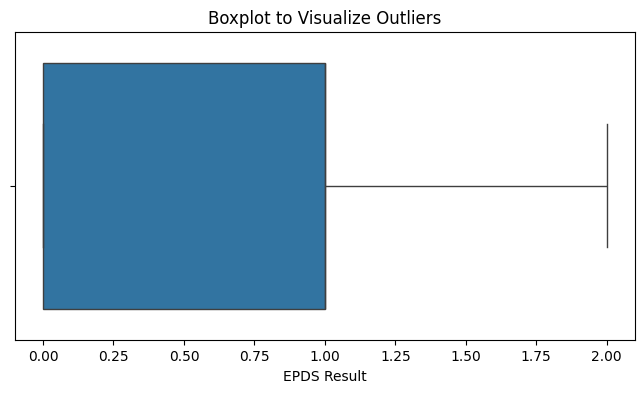

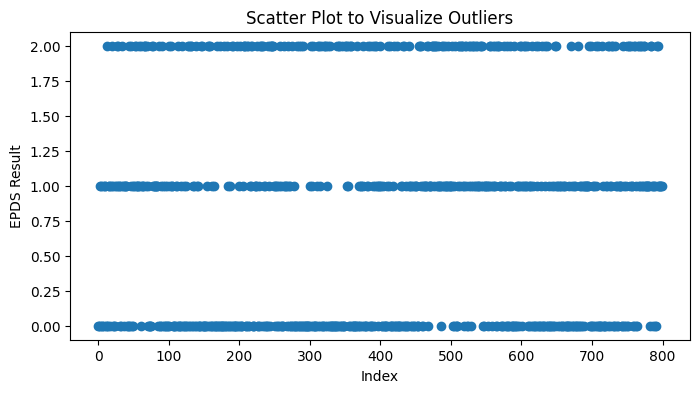

In [40]:
# Visualize outliers
## Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_encoded[column_to_check])
plt.title('Boxplot to Visualize Outliers')
plt.show()

## Scatter plot
plt.figure(figsize=(8, 4))
plt.scatter(range(len(df_encoded)), df_encoded[column_to_check])
plt.title('Scatter Plot to Visualize Outliers')
plt.xlabel('Index')
plt.ylabel(column_to_check)
plt.show()

#### Remove Outliers

In [41]:
# Remove outliers
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

df_clean = remove_outliers_iqr(df_encoded, column_to_check)
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Shape before removing outliers: {df_encoded.shape}")
print(f"Shape after removing outliers: {df_clean.shape}")

Shape before removing outliers: (800, 51)
Shape after removing outliers: (800, 51)


### Split Dataset into Training and Testing

In [42]:
# Calculate total instances and number of classes
instances = len(df_clean)
num_of_classes = df_clean['EPDS Result'].nunique()

# Determine number of samples needed per class in test set
total_test_instances = int(instances * 0.2)
test_samples_per_class = total_test_instances // num_of_classes

# Create balanced test set
test_df = df_clean.groupby('EPDS Result').sample(n=test_samples_per_class, random_state=42)
train_df = df_clean.drop(index=test_df.index)

to_remove=[
    'sr',
    'Marital status',
    'Addiction',
    'Breastfeed',
    'Pregnancy length',
    # 'Depression before pregnancy (PHQ2)', 'Depression during pregnancy (PHQ2)',
    'EPDS Result', 'PHQ9 Result', 'PHQ9 Score', 'EPDS Score',
]

# Split into features and target
X_train = train_df.drop(columns=to_remove)
y_train = train_df['EPDS Result']
X_test = test_df.drop(columns=to_remove)
y_test = test_df['EPDS Result']

### SMOTE (Synthetic Minority Oversampling Technique)
Apply SMOTE only on training data.

In [43]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

### Scale Features

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit only on training data and transform both training and testing sets
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

### Define Machine Learning Models

In [45]:
# Import Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

### Hyperparameter Tuning alongwith CV

#### Define Cross Validation (CV)

In [46]:
# Using Stratified K-Fold Cross Validation to maintain class balance
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Define Hyperparameter Grids

In [47]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    "Decision Tree": {
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 20]
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1]
    },
    "Extra Trees": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 20]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9]
    },
    "XGBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    "CatBoost": {
        'iterations': [100, 200],
        'learning_rate': [0.01, 0.1],
        'depth': [4, 6, 8]
    }
}

#### Hyperparameter Tuning using GridSearchCV

In [ ]:
import warnings
warnings.filterwarnings('ignore')

print("\n=== Hyperparameter Tuning Started ===")

best_models = {}  # To save best estimators

for name, model in models.items():
    print(f"Tuning {name}...")

    if param_grids[name]:  # If there are parameters to tune
        grid = GridSearchCV(
            model,
            param_grids[name],
            cv=cv,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train_sm_scaled, y_train_sm)
        best_models[name] = grid.best_estimator_

        print(f"Best Params for {name}: {grid.best_params_}")
    else:
        # No hyperparameter tuning (e.g., GaussianNB)
        model.fit(X_train_sm_scaled, y_train_sm)
        best_models[name] = model

print("\n=== Hyperparameter Tuning Completed ===")


=== Hyperparameter Tuning Started ===
Tuning Logistic Regression...
Best Params for Logistic Regression: {'C': 0.01, 'solver': 'liblinear'}
Tuning Decision Tree...
Best Params for Decision Tree: {'max_depth': None, 'min_samples_split': 2}
Tuning Random Forest...
Best Params for Random Forest: {'max_depth': 20, 'n_estimators': 200}
Tuning Gradient Boosting...
Best Params for Gradient Boosting: {'learning_rate': 0.2, 'n_estimators': 200}
Tuning AdaBoost...
Best Params for AdaBoost: {'learning_rate': 1, 'n_estimators': 50}
Tuning Extra Trees...
Best Params for Extra Trees: {'max_depth': 20, 'n_estimators': 200}
Tuning SVM...
Best Params for SVM: {'C': 10, 'kernel': 'rbf'}
Tuning KNN...
Best Params for KNN: {'n_neighbors': 3}
Tuning XGBoost...


#### Find out the Best Models

In [ ]:
from sklearn.model_selection import cross_val_score

print("\n=== Individual Models Evaluation (after Tuning, with 5-Fold Cross-Validation) ===")
print("{:<30} {:>20}".format('Model', 'Mean CV Accuracy'))
print("-" * 50)

individual_model_scores = {}

for name, model in best_models.items():
    scores = cross_val_score(model, X_train_sm_scaled, y_train_sm, cv=cv, scoring='accuracy')
    mean_score = scores.mean()
    individual_model_scores[name] = mean_score
    print("{:<30} {:>20.4f}".format(name, mean_score))

# Find best individual model
best_individual_model = max(individual_model_scores, key=individual_model_scores.get)
print("\n>> Best Individual Model (After Tuning):", best_individual_model,
      f"with Mean CV Accuracy: {individual_model_scores[best_individual_model]:.4f}")


=== Individual Models Evaluation (after Tuning, with 5-Fold Cross-Validation) ===
Model                              Mean CV Accuracy
--------------------------------------------------
Logistic Regression                          0.6330
Decision Tree                                0.6117
Random Forest                                0.7632
Gradient Boosting                            0.7284
AdaBoost                                     0.6397
Extra Trees                                  0.7621
SVM                                          0.7351
KNN                                          0.7048
XGBoost                                      0.7497
CatBoost                                     0.7385

>> Best Individual Model (After Tuning): Random Forest with Mean CV Accuracy: 0.7632


### Ensemble

#### Select Top 2 models for Emsemble

In [ ]:
# Find Top 2 Best Models based on CV Accuracy
top_2_models = sorted(individual_model_scores.items(), key=lambda x: x[1], reverse=True)[:2]

print("\n=== Top 2 Models Selected for Ensemble ===")
for name, score in top_2_models:
    print(f"{name}: {score:.4f}")

# Now build ensemble with these top 2 models only
selected_estimators = [(name, best_models[name]) for name, _ in top_2_models]


=== Top 2 Models Selected for Ensemble ===
Random Forest: 0.7632
Extra Trees: 0.7621


#### Define Ensemble Classifiers

In [ ]:
# Deifine Ensemble Classifier
from sklearn.ensemble import VotingClassifier

# Hard Voting
ensemble_hard = VotingClassifier(
    estimators=selected_estimators,
    voting='hard'
)

# Soft Voting
ensemble_soft = VotingClassifier(
    estimators=selected_estimators,
    voting='soft'
)

#### Evaluate Ensemble Models

In [ ]:
print("\n=== Ensemble Models Evaluation (with 5-Fold Cross-Validation) ===")
print("{:<30} {:>20}".format('Ensemble Model', 'Mean CV Accuracy'))
print("-" * 50)

ensemble_model_scores = {}

for name, model in {"Ensemble Hard Voting": ensemble_hard, "Ensemble Soft Voting": ensemble_soft}.items():
    scores = cross_val_score(model, X_train_sm_scaled, y_train_sm, cv=cv, scoring='accuracy')
    mean_score = scores.mean()
    ensemble_model_scores[name] = mean_score
    print("{:<30} {:>20.4f}".format(name, mean_score))

# Find best ensemble model
best_ensemble_model = max(ensemble_model_scores, key=ensemble_model_scores.get)
print("\n>> Best Ensemble Model (After Tuning):", best_ensemble_model,
      f"with Mean CV Accuracy: {ensemble_model_scores[best_ensemble_model]:.4f}")


=== Ensemble Models Evaluation (with 5-Fold Cross-Validation) ===
Ensemble Model                     Mean CV Accuracy
--------------------------------------------------
Ensemble Hard Voting                         0.7643
Ensemble Soft Voting                         0.7598

>> Best Ensemble Model (After Tuning): Ensemble Hard Voting with Mean CV Accuracy: 0.7643


### Final Model Training and Test for final training

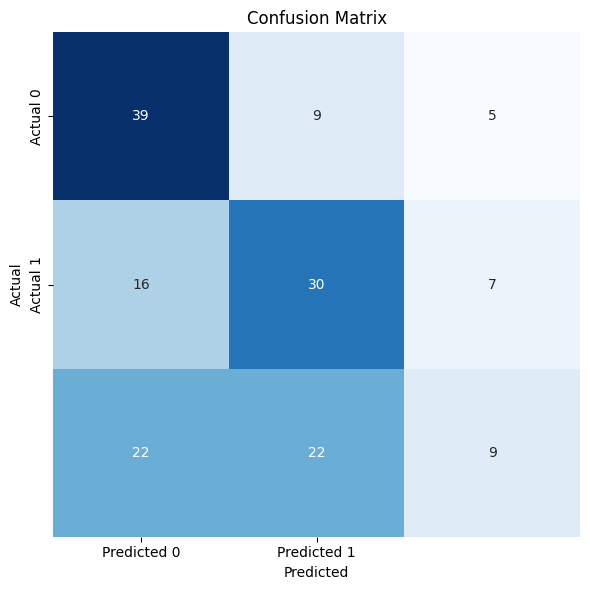

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Assuming you've already trained and tested your final model
# Replace with your model and data if needed

# Select the best ensemble model for final training (example: ensemble_soft)
final_model = ensemble_soft

# Train the final model on the full training set
final_model.fit(X_train_sm_scaled, y_train_sm)

# Predict on the test set
y_pred = final_model.predict(X_test_scaled)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()

# Save the image
# plt.savefig('confusion_matrix.png')  # Saves as an image
plt.show()  # Displays the plot

### XAI (Explainable AI) - LIME

In [ ]:
import os
# Create output folder
os.makedirs('lime_outputs', exist_ok=True)

import lime
import lime.lime_tabular

print("yo")
print([col.title() for col in X_train.columns.tolist()])

# Initialize LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,                      # Reduced feature data
    feature_names=[col.title() for col in X_train.columns.tolist()],  # First letter capitalized
    class_names=[str(cls) for cls in np.unique(y_train)],
    mode='classification'
)

# Define predict_fn
def predict_fn(x):
    return final_model.predict_proba(scaler.transform(x))

# Explain a few random samples
print("\n=== Generating LIME Explanations ===")
for idx in np.random.choice(X_test.shape[0], 5, replace=False):
    sample = X_test.iloc[idx]
    exp = explainer.explain_instance(
        data_row=sample.values,
        predict_fn=predict_fn,
        num_features=10
    )
    exp.save_to_file(f'lime_outputs/lime_explanation_sample_{idx}.html')
    print(f"✅ Saved lime_outputs/lime_explanation_sample_{idx}.html")

print("\n✅ All LIME explanations saved inside 'lime_outputs/' folder.")

yo
['Age', 'Residence', 'Education Level', 'Occupation Before Latest Pregnancy', 'Monthly Income Before Latest Pregnancy', 'Occupation After Your Latest Childbirth', 'Current Monthly Income', "Husband'S Education Level", 'Husband’S Monthly Income', 'Total Children', 'Disease Before Pregnancy', 'History Of Pregnancy Loss', 'Family Type', 'Number Of Household Members', 'Relationship With The In-Laws', 'Relationship With Husband', 'Relationship With The Newborn', 'Relationship Between Father And Newborn', 'Feeling About Motherhood', 'Recieved Support', 'Need For Support', 'Major Changes Or Losses During Pregnancy', 'Abuse', 'Trust And Share Feelings', 'Number Of The Latest Pregnancy', 'Pregnancy Plan', 'Regular Checkups', 'Fear Of Pregnancy', 'Diseases During Pregnancy', 'Age Of Newborn', 'Age Of Immediate Older Children', 'Mode Of Delivery', 'Gender Of Newborn', 'Birth Compliancy', 'Newborn Illness', 'Worry About Newborn', 'Relax/Sleep When Newborn Is Tended ', 'Relax/Sleep When The Newb